# A first look at PUNCH data with the RHEF filter

This notebook is for absolute beginners: to Python, to Jupyter, and to
coronagraph images. In four short steps we will download one real image from
NASA's PUNCH mission, look at it, sharpen it with a filter called **RHEF**, and
make one nice figure.

The whole thing takes about five minutes, most of which is a single 25 MB
download.

**What is RHEF?** The corona (the Sun's atmosphere) is millions of times
brighter near the Sun than far from it, so an ordinary image shows either a
blown-out center or a black outer field, never both. The Radial Histogram
Equalizing Filter fixes this by, in essence, adjusting the exposure separately
at every distance from the Sun. Faint wisps far out become just as visible as
the bright inner corona.

## Before you start

You need **Python 3.12 or newer** and Jupyter. If you already have both, skip to
Step 0.

If you do not, the shortest path is:

1. Install Python 3.12 or newer from
   [python.org/downloads](https://www.python.org/downloads/). If you use conda
   instead: `conda create -n punch python=3.12 -y` then `conda activate punch`.
2. In a terminal, install Jupyter: `pip install jupyterlab`
3. Start it from the folder that holds this file: `jupyter lab`
4. A browser tab opens. Click `rhef_punch_beginner.ipynb`.

**Running a cell:** click a gray code cell and press **Shift+Enter**. Run the
cells in order, top to bottom. Each one prints or draws something when it
finishes.

**Which Python you are actually using:** the top right of the Jupyter window
shows the kernel name. The first code cell checks the version for you and says
what to do if it is too old.

**If a cell stops:** read the last few lines of the message. Every stopping
point in this notebook prints a plain-English reason and the next thing to try.
The two most common causes are no internet connection and an old Python.

## Step 0: install the tools

This cell checks your Python version, then installs the packages we need. The
main ones: `sunpy` handles solar images, and `sunkit-image` contains the RHEF
filter.

Running it again later is harmless, with one exception. If pip *upgrades* a
package you have already used in this session, the old version stays loaded
until you restart the kernel (menu: Kernel > Restart Kernel).

In [1]:
import sys

if sys.version_info < (3, 12):
    raise SystemExit(
        f"This notebook needs Python 3.12 or newer.\n"
        f"This kernel is running {sys.version.split()[0]}.\n\n"
        "To fix it: in the Jupyter menu choose Kernel > Change Kernel, and pick a\n"
        "Python 3.12 or newer kernel. If the list does not offer one, close Jupyter\n"
        "and follow the 'Before you start' section at the top of this notebook."
    )

%pip install -q sunpy "sunkit-image>=0.7" punchbowl

print("All set. Running Python", sys.version.split()[0])

Note: you may need to restart the kernel to use updated packages.
All set. Running Python 3.12.9


## Step 1: download one PUNCH image

PUNCH images live in a public NASA archive. We ask for them with `Fido`,
sunpy's search tool (sort of like a search engine for solar data). Here we
request one *mosaic*, the combined view from all four PUNCH spacecraft, from
May 11, 2026.

We want the **CAM** product: the clear average mosaic. PUNCH builds it by
averaging over its repeating pointing pattern, which trades time resolution for
a much cleaner image covering the full circular field. One arrives about every
32 minutes, so the two-hour window below finds a few and we take the first.

The file is about 25 MB and lands in a new `punch_data/` folder next to this
notebook. Expect anywhere from a few seconds to a minute, with no progress bar
while it works.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')     # keeps the output readable; see the closing note

# Works around a version clash between parfive 2.2 and aiohttp 3.12: parfive asks
# for "no time limit" by sending 0, and aiohttp now rejects 0. Without this the
# download fails instantly with a confusing ssl_handshake_timeout message.
os.environ.setdefault("PARFIVE_TOTAL_TIMEOUT", "600")

import punchbowl                      # registers PUNCH with sunpy's search
from concurrent.futures import ThreadPoolExecutor
from sunpy.net import Fido, attrs as a

result = Fido.search(
    a.Time("2026-05-11 12:00", "2026-05-11 14:00"),   # a two-hour window
    a.Source("PUNCH"),                                # the mission
    a.Level("3"),                                     # science-ready data
    a.punch.ProductCode("CA"), a.Instrument("M"),     # CA + M = CAM,
)                                                     # the clear average mosaic

n_found = sum(len(table) for table in result)
if n_found == 0:
    raise SystemExit(
        "The search came back empty, so there is nothing to download.\n\n"
        "This almost always means one of two things:\n"
        "  1. No internet connection right now (the archive is a NASA website).\n"
        "  2. The date was changed to a day PUNCH has no data for.\n\n"
        "Check your connection, then run this cell again.\n"
        "If you are on a work network, a VPN or proxy can also block the archive."
    )

print(f"Found {n_found} image(s). Downloading the first one, about 25 MB ...")

# The download runs in a helper thread; this avoids a harmless but
# scary-looking warning that Jupyter sometimes prints otherwise.
with ThreadPoolExecutor(1) as pool:
    files = pool.submit(lambda: Fido.fetch(result[0][0], path='punch_data/{file}',
                                           progress=False)).result()

if len(files) == 0:
    raise SystemExit(
        "The search worked, but the file did not finish downloading.\n\n"
        "This is nearly always a connection dropped partway through.\n"
        "Run this cell again; it will resume rather than start over."
    )

print("Downloaded:", files[0])

Found 4 image(s). Downloading the first one, about 25 MB ...


Downloaded: punch_data/PUNCH_L3_CAM_20260511120000_v0l.fits


## Step 2: look at the raw image

First we open the file as a sunpy `Map` (an image that knows where the Sun is)
and shrink it to a comfortable working size. Then we draw it twice, to show why
this data is hard to look at.

**What you should see.** On the left, almost nothing: a flat wash of one colour.
The corona covers such an enormous brightness range that a plain linear display
puts nearly every pixel at the same tone. On the right, a percentile stretch
rescues the image and reveals the actual problem: a searing ring around the
occulter, and an outer field that stays dark and grainy. Neither view shows the
whole corona at once.

The black disc at the centre is the occulter, the mask that blocks direct
sunlight so the faint corona can be seen at all. The dark corners are outside
the region the cameras cover.

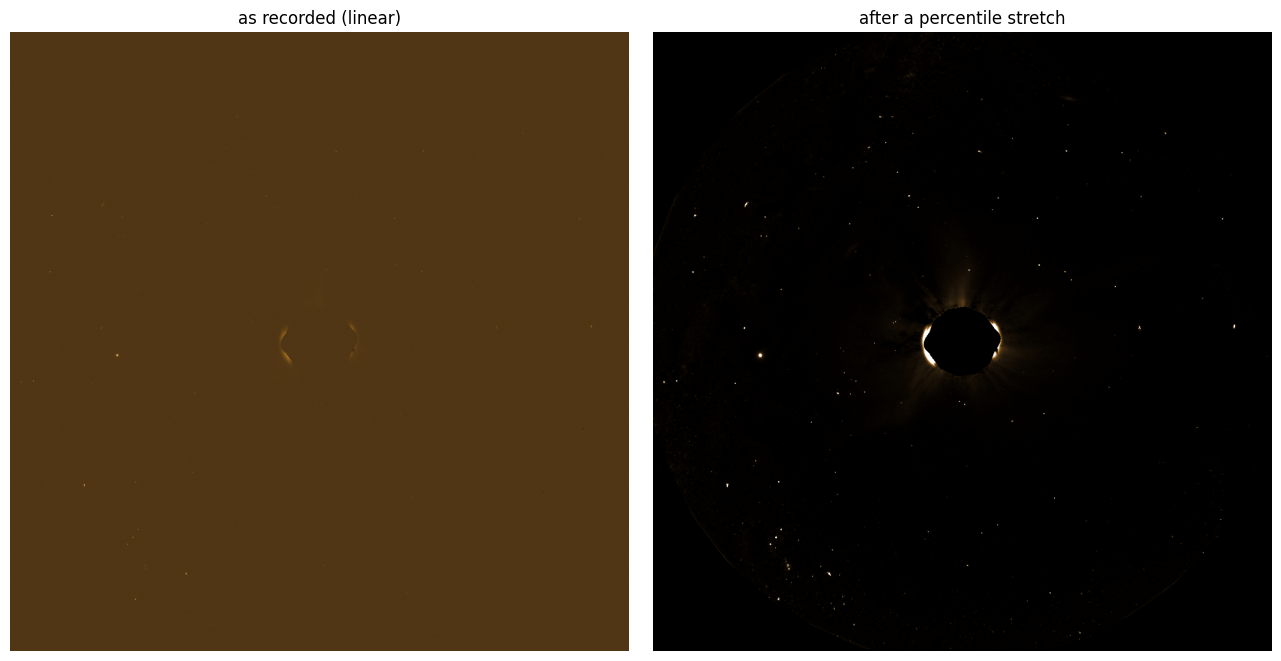

In [3]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import sunpy.map

m = sunpy.map.Map(files[0])[0]                 # the file holds 2 layers:
                                               # [0] is the image, [1] its uncertainty
m = m.resample([1024, 1024] * u.pix)           # smaller = faster, plenty for a look

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

axes[0].imshow(m.data, origin="lower", cmap="punch")
axes[0].set_title("as recorded (linear)")

axes[1].imshow(m.data, origin="lower", cmap="punch",
               vmin=np.nanpercentile(m.data, 5),
               vmax=np.nanpercentile(m.data, 99.95))
axes[1].set_title("after a percentile stretch")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3: apply the RHEF filter

This is the whole trick: one line. `rhef` works out all its own settings, and
the result comes back with the official PUNCH colormap already attached.

**What you should see:** the same circular field, but now streamers reach from
the occulter all the way to the edge, at one readable contrast. Hold it against
either panel from Step 2. The bright ring is gone and the dark outer field is
full of structure. That is the whole point of the filter.

**Why the corners turn flat orange:** roughly a fifth of this image is no-data,
the square corners outside the circular field, stored as exact zeros. RHEF
equalizes brightness at every radius, so it lifts those zeros to a mid-tone
along with everything else. It is an artifact of filtering empty pixels, not a
result. Step 4 hides that region so it cannot be mistaken for signal.

If you would like to experiment, `rhef` has one knob called `upsilon` that sets
how strong the effect is: try `rhef(m, upsilon=0.1)` for a gentler look (the
default is 0.35).

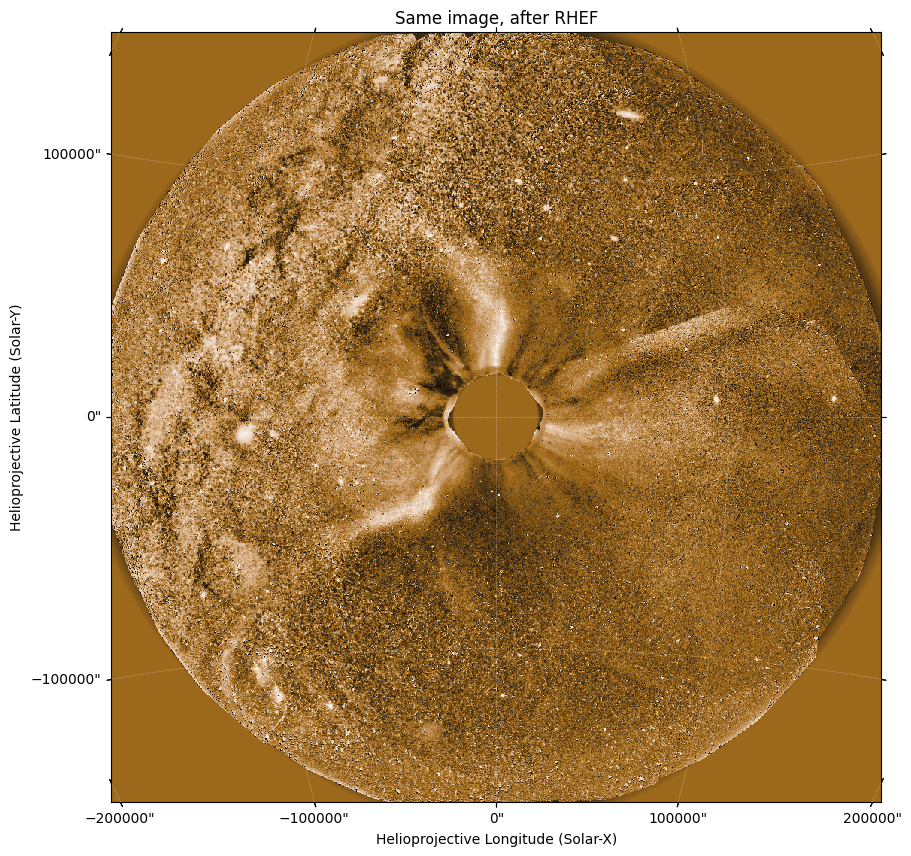

In [4]:
from sunkit_image.radial import rhef

filtered = rhef(m)                             # <-- the filter

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection=filtered)
filtered.plot(axes=ax)
ax.set_title("Same image, after RHEF")
plt.show()

## Step 4: one nice figure

To finish, a publication-style version of the filtered image: rings marking
distance from the Sun in solar radii (the Sun's own radius, about 700,000 km),
and a colorbar. You do not need to understand every line; it is all just
matplotlib decoration around the same `filtered` image.

It is drawn on white rather than black. A dark figure looks good on a screen, but
journals print on paper, so a white ground is what a figure needs to survive
submission.

The one line that is not decoration is the mask: the no-data corners from Step 3
are set to NaN, which matplotlib draws as transparent, so the grey panel behind
shows through. Grey rather than white on purpose, so a reader can tell missing
data from the page. Only pixels the cameras actually recorded are coloured, and
that includes the disc at the centre, where the occulter blocks the Sun.

**The colorbar is not calibrated.** RHEF is a visualization transform: it replaces
each pixel with its rank within its radial annulus, the ring of pixels at its own
distance from the Sun, so the output is a bounded 0 to 1 display quantity, not a
calibrated radiance. It is the right thing to show a reader and the wrong thing to
measure. Any photometry, mass estimate or brightness ratio must come from the
original calibrated PUNCH product, not from this array.

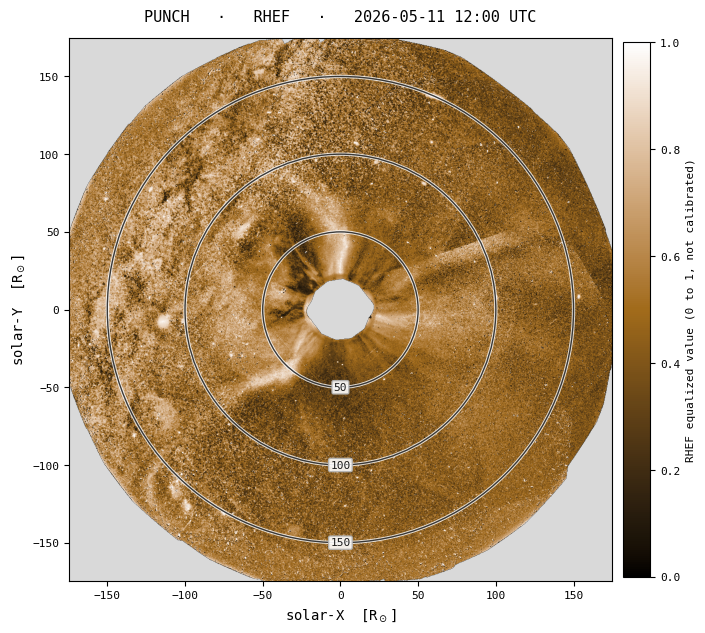

In [5]:
import numpy as np
from matplotlib.patches import Circle
from matplotlib import patheffects as pe

# how far the image edge is from the Sun, measured in solar radii
r_max = (m.data.shape[1] / 2) * m.scale[0].to_value(u.arcsec / u.pix) / m.rsun_obs.to_value(u.arcsec)

# hide the no-data corners: they are exact zeros in the raw image, and RHEF
# lifts them to a mid-tone. NaN draws as the white page instead.
shown = np.where(m.data == 0, np.nan, filtered.data)

# White ground, because journals print on paper. The rings get a white outline so
# they stay readable over the bright streamers and the dark inner corona alike.
halo = [pe.withStroke(linewidth=2.4, foreground="white", alpha=0.8)]

with plt.rc_context({"font.family": "monospace"}):
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    ax.set_facecolor("0.85")               # the masked pixels are NaN, so they are
                                           # transparent and this grey shows through:
                                           # missing data is visibly not white page
    im = ax.imshow(shown, origin="lower", extent=[-r_max, r_max, -r_max, r_max],
                   cmap="punch", vmin=0, vmax=1)
    for rr in (50, 100, 150):                  # distance rings, in solar radii
        ax.add_patch(Circle((0, 0), rr, fill=False, ec="0.15", lw=1.0,
                            alpha=0.9, path_effects=halo))
        ax.text(0, -rr, str(rr), color="0.1", fontsize=8, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="0.7", alpha=0.9))
    ax.set_xlim(-r_max, r_max); ax.set_ylim(-r_max, r_max)
    ax.tick_params(labelsize=8)
    ax.set_xlabel(r"solar-X  [R$_\odot$]")
    ax.set_ylabel(r"solar-Y  [R$_\odot$]")
    ax.set_title(rf"PUNCH   ·   RHEF   ·   {m.date.iso[:16]} UTC", fontsize=11, pad=12)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label("RHEF equalized value (0 to 1, not calibrated)", fontsize=8)
    cb.ax.yaxis.set_tick_params(labelsize=8)
plt.show()

## Where to go next

That is the whole pipeline: download, look, filter, figure.

**To try a different day:** edit the two dates on the `a.Time(...)` line in
Step 1 and re-run from there. PUNCH data begins in 2025. Keep the window at a
couple of hours or more, since CAM mosaics arrive only about every 32 minutes.

**Where the files went:** the `punch_data/` folder next to this notebook.
Delete it whenever you like; Step 1 will simply download again.

**About that warnings line:** Step 1 switches off Python warnings for the rest
of the session to keep the output readable. Once you start doing your own
analysis, delete that line so you can see what the libraries are telling you.

The companion notebook `make_rhef_videos.ipynb` goes further: many frames,
movies, the `upsilon` knob in detail, and the one pitfall to avoid
(`radial_bin_edges`).

_The RHEF paper:_ [Gilly & Cranmer 2025](https://doi.org/10.1007/s11207-025-02578-x) ·
_API docs:_ [`sunkit_image.radial.rhef`](https://docs.sunpy.org/projects/sunkit-image/en/stable/api/sunkit_image.radial.rhef.html)